# Исследование данных по кредитам. Разведочный анализ.

Give Me Some Credit — датасет финансовой организации, опубликованный на Kaggle в 2011 году для задачи бинарной классификации кредитного риска.

Общие параметры

Объем: 150 000 строк, 11 столбцов.

Цель: предсказание вероятности просрочки платежа по кредиту на 90 и более дней в течение ближайших двух лет.

Целевая переменная: SeriousDlqin2yrs (1 — просрочка была, 0 — не было).

Распределение классов: 6,68% позитивных меток (10 026) и 93,32% негативных (139 974).

# Описание атрибутов

SeriousDlqin2yrs (int): целевой признак (0 или 1).

RevolvingUtilizationOfUnsecuredLines (float): отношение текущей задолженности по кредитным картам и доверительным линиям к общему кредитному лимиту.

age (int): возраст заемщика в годах (от 0 до 109 лет; значение 0 является единичной ошибкой).

NumberOfTime30-59DaysPastDueNotWorse (int): количество задержек выплат на срок от 30 до 59 дней за последние 2 года.

DebtRatio (float): отношение ежемесячных долговых выплат к ежемесячному доходу.

MonthlyIncome (float): ежемесячный доход заемщика. Содержит 29 731 пропуск (19,8% данных).

NumberOfOpenCreditLinesAndLoans (int): количество открытых кредитов (автокредиты, ипотека) и кредитных карт.

NumberOfTimes90DaysLate (int): количество задержек выплат на 90 и более дней за последние 2 года.

NumberRealEstateLoansOrLines (int): количество ипотечных кредитов и кредитных линий под залог недвижимости.

NumberOfTime60-89DaysPastDueNotWorse (int): количество задержек выплат на срок от 60 до 89 дней за последние 2 года.

NumberOfDependents (int): количество иждивенцев в семье (исключая самого заемщика).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from lightgbm import early_stopping
from sklearn.metrics import f1_score, precision_recall_curve, confusion_matrix
import shap
import optuna
import warnings
from sklearn.metrics import roc_curve, auc

c:\Users\Admin\Documents\DSTU\donstu-projects\credits\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Загрузка и получение базовой информации о данных

In [2]:
df = pd.read_csv('GiveMeSomeCreditTrain.csv', encoding='utf-8')
df = df.drop(columns=['Unnamed: 0'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      105000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  105000 non-null  float64
 2   age                                   105000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  105000 non-null  int64  
 4   DebtRatio                             105000 non-null  float64
 5   MonthlyIncome                         84205 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       105000 non-null  int64  
 7   NumberOfTimes90DaysLate               105000 non-null  int64  
 8   NumberRealEstateLoansOrLines          105000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  105000 non-null  int64  
 10  NumberOfDependents                    102262 non-null  float64
dtypes: float64(

In [3]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,105000.000000,105000.000000,105000.00000,105000.000000,105000.000000,8.420500e+04,105000.000000,105000.000000,105000.000000,105000.000000,102262.000000
mean,0.066838,6.146972,52.22161,0.419933,354.160487,6.700439e+03,8.440276,0.265105,1.016429,0.239286,0.756850
std,0.249743,217.681366,14.76568,4.188991,1999.455352,1.536821e+04,5.130889,4.166023,1.133977,4.151858,1.114183
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029939,41.00000,0.000000,0.174872,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154674,52.00000,0.000000,0.366143,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.561067,63.00000,0.000000,0.869178,8.250000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,22198.000000,109.00000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,13.000000


In [4]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           20795
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       2738
dtype: int64

Логично было бы заменить пропущенные значения в столбцах модой, чтобы графики показывали более точные данные, а также чтобы мы не потеряли ценную информацию в этих записях.

In [5]:
missing_values_columns = [column for column in df.columns if df[column].isnull().sum() != 0]
df['NAN_found'] = df[['MonthlyIncome', 'NumberOfDependents']].isnull().any(axis=1).astype(int)
for column_name in missing_values_columns:
    df[column_name] = df[column_name].fillna(df[column_name].median())
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
NAN_found                               0
dtype: int64

Теперь сделаем коробчатые диаграммы и гистограммы для каждого столбца, чтобы удостовериться в правильности заполнения и чтобы наглядно наблюдать за аномальными значениями.

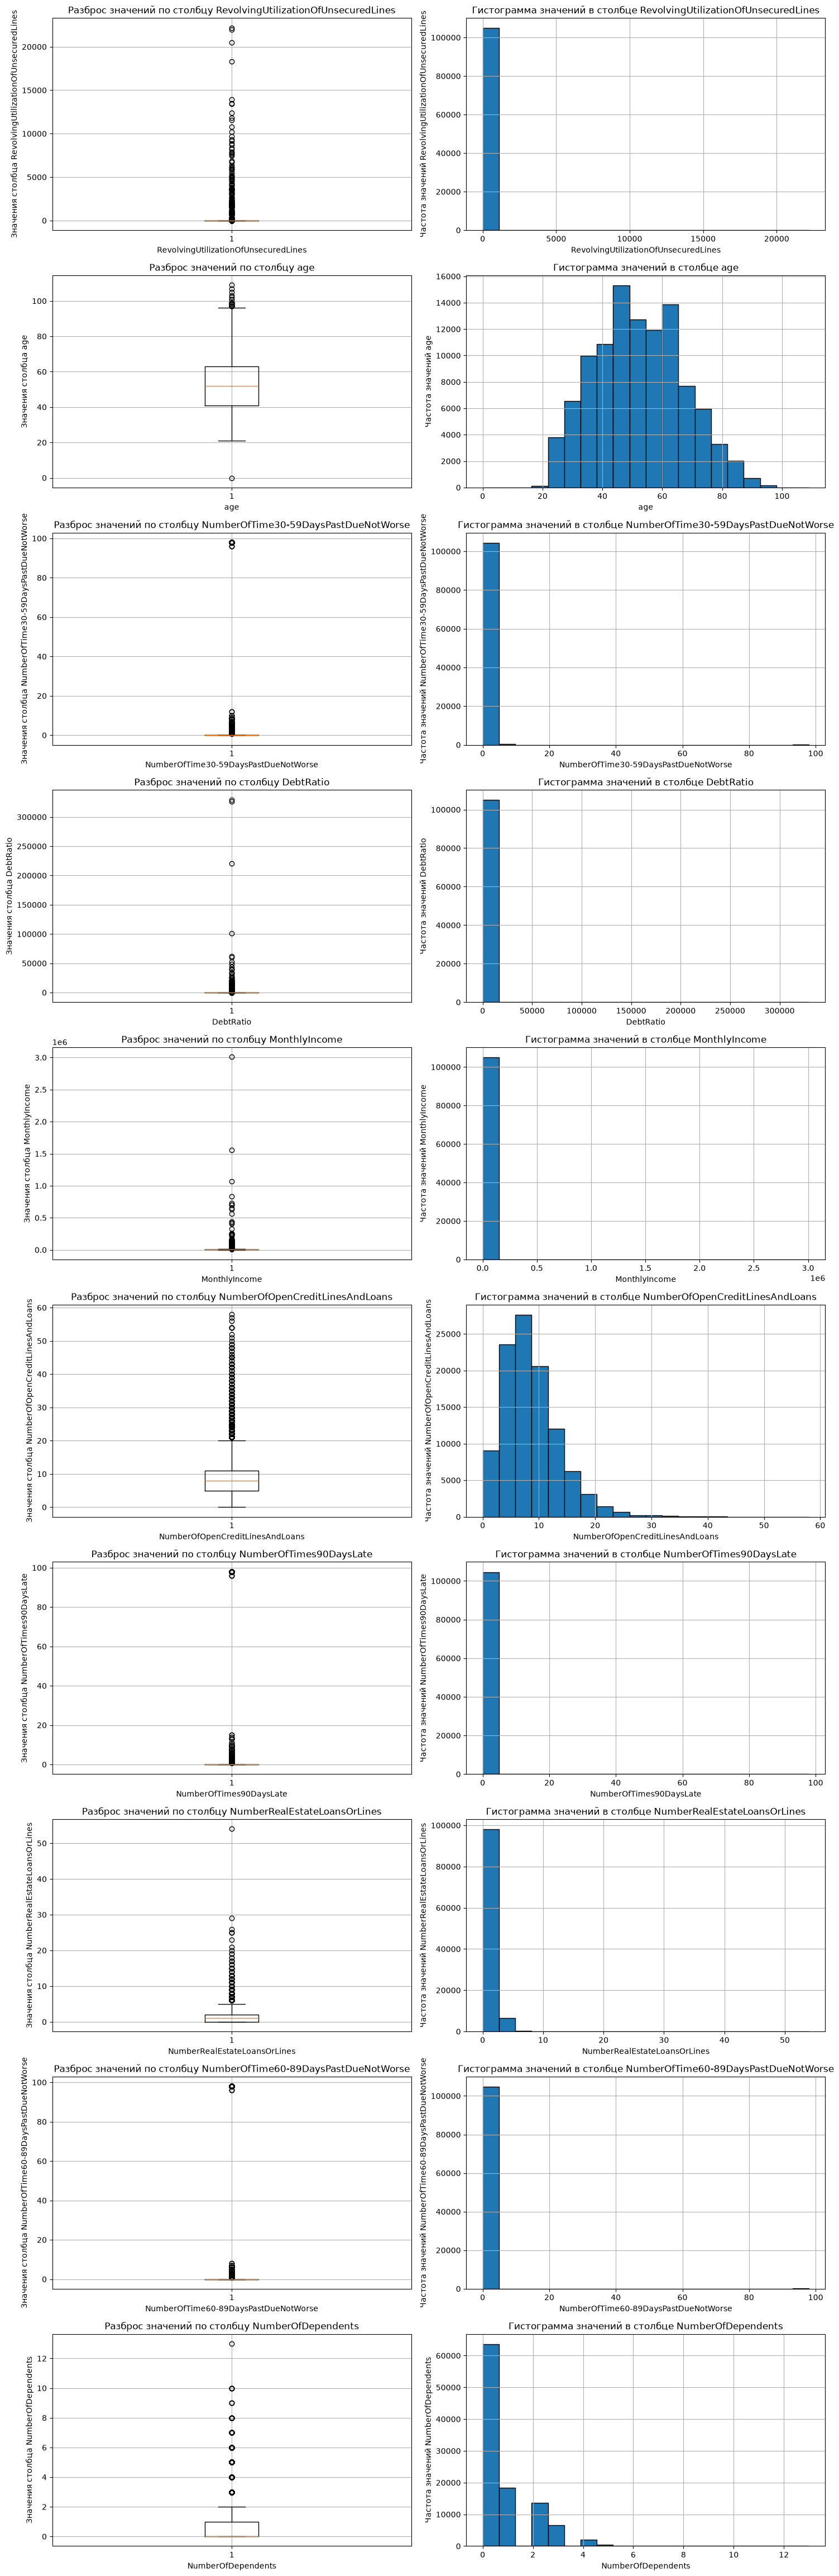

In [6]:
n_cols = len(df.columns)
plt.figure(figsize=(15, 55))
for i, col_name in enumerate(df.columns[1:-1]):
    plt.subplot(n_cols, 2, 2 * i + 1)
    plt.boxplot(df[col_name])
    plt.title(f'Разброс значений по столбцу {col_name}')
    plt.xlabel(f'{col_name}')
    plt.ylabel(f'Значения столбца {col_name}')
    plt.grid(True)

    plt.subplot(n_cols, 2, 2 * i + 2)
    plt.hist(df[col_name], bins=20, edgecolor='black')
    plt.title(f'Гистограмма значений в столбце {col_name}')
    plt.ylabel(f'Частота значений {col_name}')
    plt.xlabel(f'{col_name}')
    plt.grid(True)


plt.tight_layout()

### 2. Обработка выбросов

In [7]:
df.loc[df['age'] == 0, 'age'] = df['age'].median()

Кроме исправленного аномального возраста также заметим предельные значения в столбцах NumberOfTime30-59DaysPastDueNotWorse и NumberOfTime60-89DaysPastDueNotWorse, которые содержат коды ошибок. Их заменим медианой.

Строка, содержащая только числа 52 (ошибочная) была удалена для предотвращения аномалий в новом столбце 'NAN_found', который показывает были ли пропущенные значения в столбце до заполнения медианой.

In [8]:
df.groupby('NAN_found')[['MonthlyIncome', 'NumberOfDependents']].sum()

,MonthlyIncome,NumberOfDependents
NAN_found,,
0,564210484.0,71560.0
1,112293000.0,5837.0


In [9]:
df[(df['NumberOfTime30-59DaysPastDueNotWorse'] | df['NumberOfTime60-89DaysPastDueNotWorse']) > df['NumberOfTime30-59DaysPastDueNotWorse'].quantile(0.995)].sample(5)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,NAN_found
64248,1,0.965473,41,6,0.845593,7000.0,17,0,4,1,2.0,0
48585,1,1.000000,65,98,0.026164,3477.0,0,98,0,98,1.0,0
103132,1,0.890107,46,3,0.986361,3885.0,12,0,3,4,3.0,0
13572,0,0.925515,54,2,0.282475,6966.0,7,0,0,5,0.0,0
46637,0,0.967961,35,7,0.195991,8081.0,13,0,0,1,1.0,0


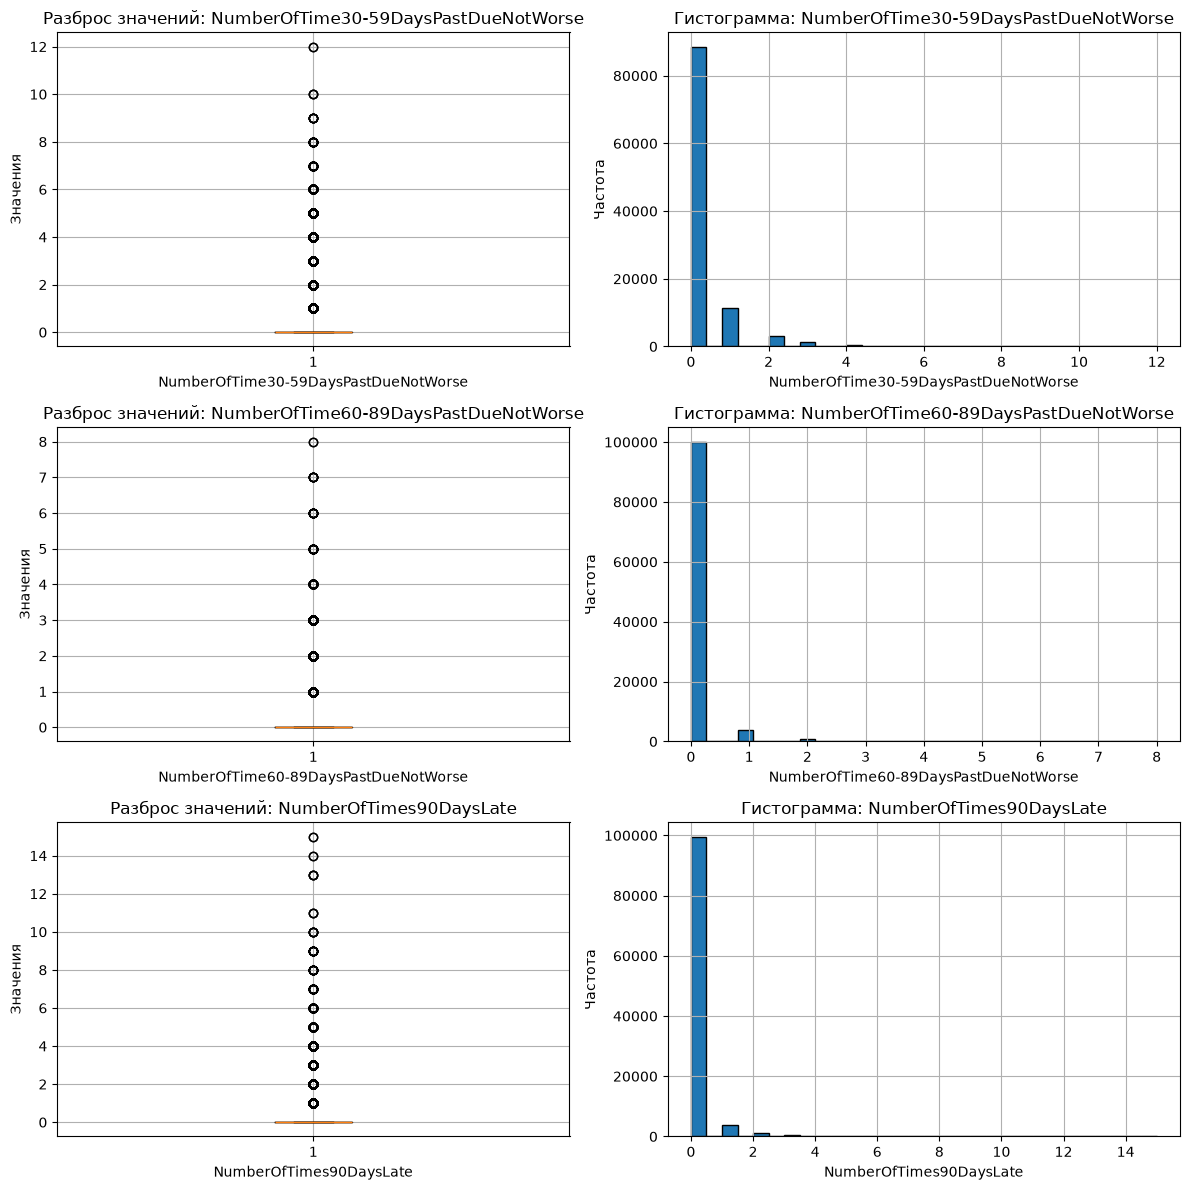

In [10]:
error_codes = [96, 98]
error_columns = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
]

df[error_columns] = df[error_columns].replace(error_codes, np.nan)

for col in error_columns:
    col_median = df[col].median()
    df[col] = df[col].fillna(col_median)

num_cols = len(error_columns)
plt.figure(figsize=(12, 12))

for i, col_name in enumerate(error_columns):
    plt.subplot(num_cols, 2, 2 * i + 1)
    plt.boxplot(df[col_name])
    plt.title(f'Разброс значений: {col_name}')
    plt.xlabel(col_name)
    plt.ylabel('Значения')
    plt.grid(True)

    plt.subplot(num_cols, 2, 2 * i + 2)
    plt.hist(df[col_name], bins=30, edgecolor='black')
    plt.title(f'Гистограмма: {col_name}')
    plt.xlabel(col_name)
    plt.ylabel('Частота')
    plt.grid(True)

plt.tight_layout()

Для аномально больших значений из столбцов используем клиппирование по 99 перцентилю.

In [11]:
def clipping(attributes, lower_gap, higher_gap):
    attributes_clean = attributes.copy()
    for col in attributes:
        attribute_lower = attributes_clean[col].quantile(lower_gap)
        attribute_higher = attributes_clean[col].quantile(higher_gap)
        attributes_clean[col] = attributes_clean[col].clip(lower=attribute_lower, upper=attribute_higher)
    return attributes_clean

df[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']] = \
    clipping(df[['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']], lower_gap=0.00, higher_gap=0.99)

### 3. Создание новых признаков 

Cоздаем новые столбцы, показывающие склонность заемщика к просрочкам а также столбец месячной выплаты по долгам

In [12]:
df['TotalPastDue'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] + 
    df['NumberOfTime60-89DaysPastDueNotWorse'] + 
    df['NumberOfTimes90DaysLate']
)
df['HasAnyPastDue'] = (df['TotalPastDue'] > 0).astype(int)
df['MonthlyDebt'] = df['MonthlyIncome'] * df['DebtRatio']
df[['TotalPastDue', 'HasAnyPastDue', 'MonthlyDebt']].sample(3)

,TotalPastDue,HasAnyPastDue,MonthlyDebt
15006,0.0,0,3.225778e+02
85616,0.0,0,6.517800e+06
23675,0.0,0,2.106000e+05


### 4. Создание тепловой карты признаков

Создаем тепловую карту чтобы понять, какие признаки коррелируют с меткой класса и насколько сильно (затем будут использованы при отборе признаков)

<Axes: >

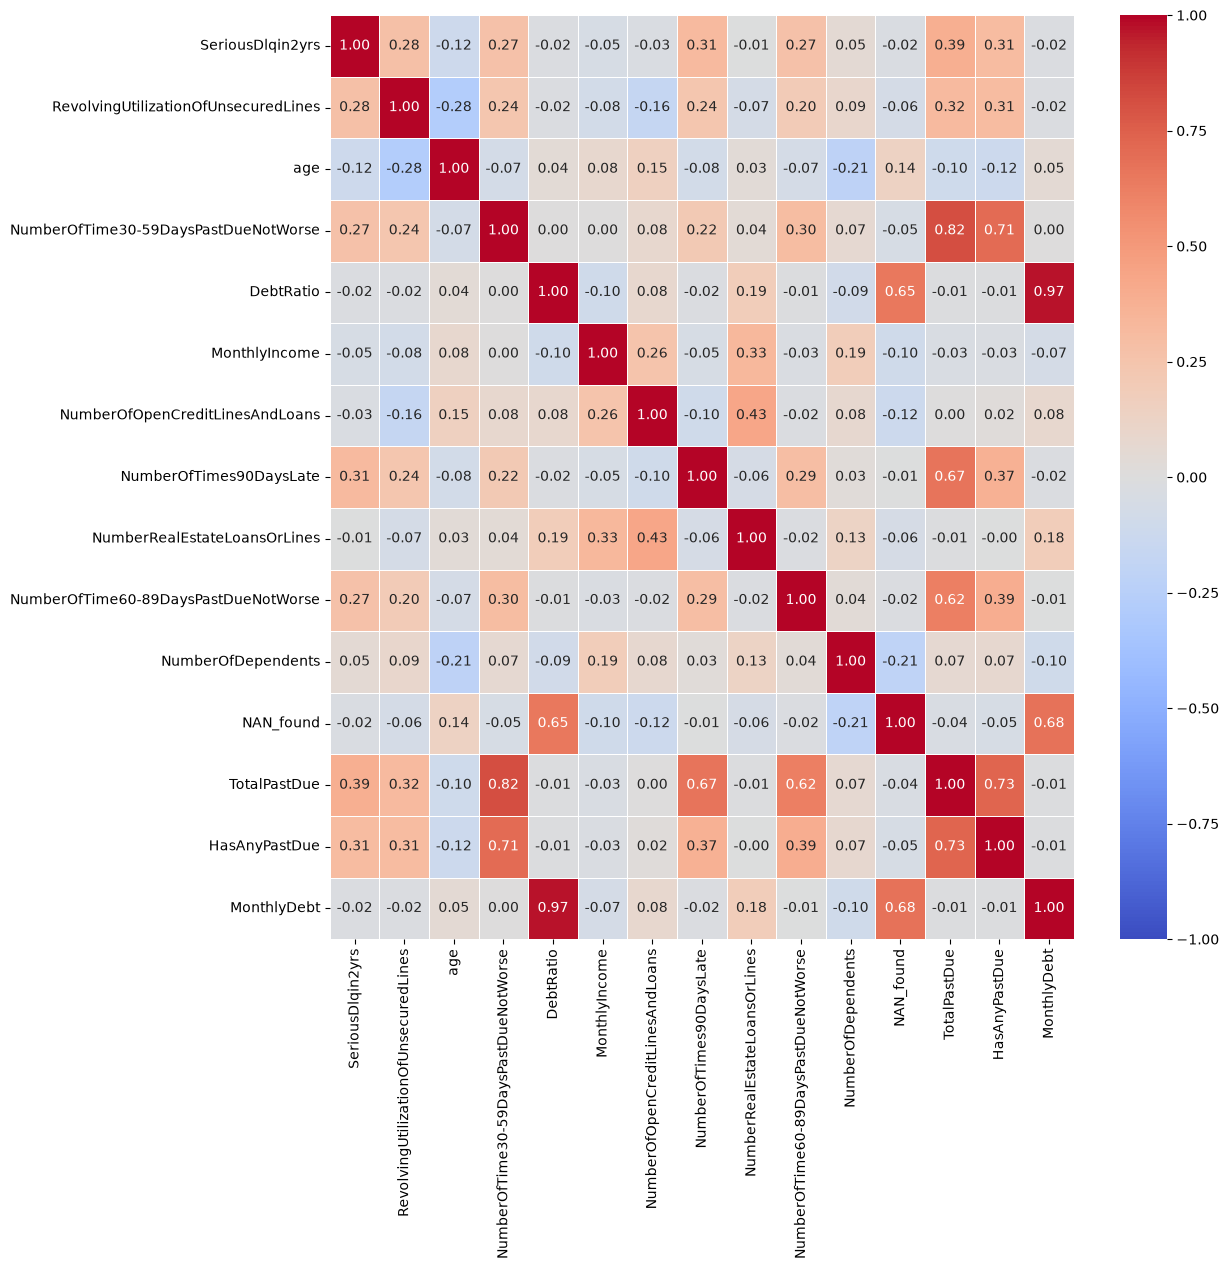

In [13]:
corr_matrix = df.corr()
corr_matrix.round(2)
plt.figure(figsize=(12,12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

Наибольшую положительную корреляцию с целевой переменной SeriousDlqin2yrs показывают созданный агрегированный признак TotalPastDue (0.39) и частые тяжелые просрочки NumberOfTimes90DaysLate (0.31). Возраст (age) имеет обратную связь (-0.12) — более старшие клиенты менее склонны к дефолту.

Выявлена сильная линейная связь (0.98) между DebtRatio и MonthDebt, а также высокая корреляция (0.82) между TotalPastDue и исходными столбцами просрочек. Для исключения дублирования информации из модели исключается признак с высокой мультиколлинеарностью, а созданный TotalPastDue сохраняется как наиболее информативный. Дабы ускорить процесс, не прибегая к обратному отбору признаков из sklearn, удалим их вручную.

In [14]:
cols_to_drop = ['SeriousDlqin2yrs', 'MonthlyDebt', 'TotalPastDue'] 

X = df.drop(columns=cols_to_drop)
y = df['SeriousDlqin2yrs']

### 5. Тестирование модели

In [15]:
first_class = (y == 1).sum()
second_class = (y == 0).sum()
print(first_class)
print(second_class)
print(f'Два класса распределились в соотношении {(second_class / len(y)) * 100:.2f}% к {(first_class / len(y)) * 100:.2f}%')

7018
97982
Два класса распределились в соотношении 93.32% к 6.68%


Наблюдаем сильный дисбаланс классов. Проверим предсказательную способность на робастном LightGBM

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scale_weight = first_class / second_class
lgb = LGBMClassifier(
    scale_pos_weight=scale_weight,
    n_estimators=300,
    learning_rate=0.01,
    max_depth=6,
    verbose=-1
)
print('Обучение...')
lgb = lgb.fit(x_train, y_train)
y_pred = lgb.predict_proba(x_test)
auc_score = roc_auc_score(y_test, y_pred[:, 1])
print(f"Результат валидации LightGBM (ROC-AUC): {auc_score:.5f}")

Обучение...
Результат валидации LightGBM (ROC-AUC): 0.85895


Визуализируем распределение вероятностей

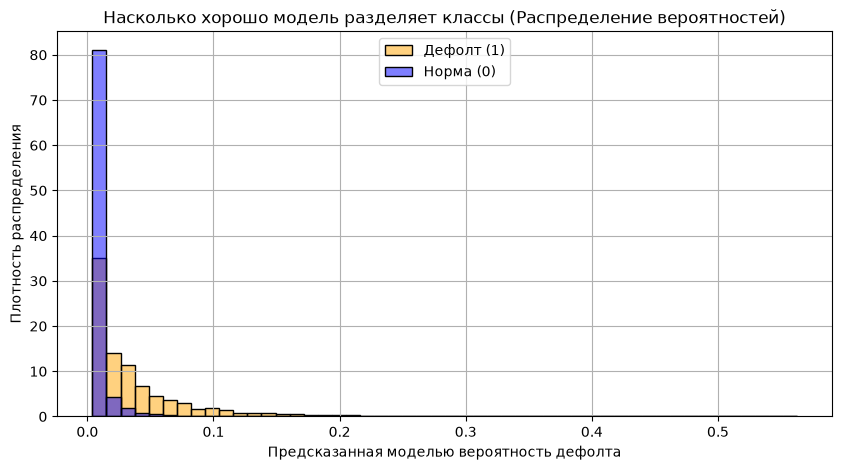

In [17]:
df_viz = pd.DataFrame({
    'true_class': y_test.values,
    'predicted_prob': y_pred[:, 1]
})

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_viz, 
    x='predicted_prob', 
    hue='true_class', 
    bins=50, 
    stat='density', 
    common_norm=False, 
    palette={0: 'blue', 1: 'orange'},
    alpha=0.5
)

plt.title('Насколько хорошо модель разделяет классы (Распределение вероятностей)', fontsize=12)
plt.xlabel('Предсказанная моделью вероятность дефолта', fontsize=10)
plt.ylabel('Плотность распределения', fontsize=10)
plt.grid(True)
plt.legend(['Дефолт (1)', 'Норма (0)'], loc='upper center');

### 6. Настройка схемы валидации метрик. Применение Stratified K-fold

Из-за выраженного дисбаланса классов в задаче кредитного скоринга (малая доля просрочек/дефолтов), обычное случайное деление может исказить пропорции целевой переменной. Стратификация гарантирует, что процент дефолтных и успешных кредитов будет одинаковым во всех обучающих и валидационных фолдах.

In [18]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)
scores = []
probabilities = np.zeros(len(X))
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    x_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    x_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    lgbm = LGBMClassifier(
        random_state=1,
        n_estimators=1000
    )
    lgbm.fit(
        x_train,
        y_train,
        eval_set=[(x_test, y_test)],
        eval_metric='auc',
        callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
        )
    y_pred = lgb.predict_proba(x_test)[:, 1]
    score = roc_auc_score(y_test, y_pred)
    scores.append(score)
    print(f'Фолд {fold+1} ROC-AUC: {score:.4f}')

    probabilities[test_idx] = y_pred

print(f'Средний ROC-AUC по всем фолдам: {np.mean(scores):.4f}')
scores_std = np.std(scores)
print(f'Стандартное отклоение по фолдам: {scores_std:.5f}')

total_roc_auc = roc_auc_score(y, probabilities)
print(f'Общий показатель ROC-AUC после K-fold: {total_roc_auc:.5f}')    

c:\Users\Admin\Documents\DSTU\donstu-projects\credits\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Фолд 1 ROC-AUC: 0.8517


c:\Users\Admin\Documents\DSTU\donstu-projects\credits\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Фолд 2 ROC-AUC: 0.8686


c:\Users\Admin\Documents\DSTU\donstu-projects\credits\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Фолд 3 ROC-AUC: 0.8589


c:\Users\Admin\Documents\DSTU\donstu-projects\credits\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Фолд 4 ROC-AUC: 0.8746


c:\Users\Admin\Documents\DSTU\donstu-projects\credits\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Фолд 5 ROC-AUC: 0.8637
Средний ROC-AUC по всем фолдам: 0.8635
Стандартное отклоение по фолдам: 0.00786
Общий показатель ROC-AUC после K-fold: 0.86349


### 7. Подбор порога классификации

Шаг состоит из двух частей: сначала находим оптимальную границу (порог), при которой клиент считается рискованным, а затем строим наглядную таблицу (матрицу ошибок), чтобы увидеть реальные успехи и промахи модели.

In [19]:
precisions, recalls, thresholds = precision_recall_curve(
    y, probabilities
)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f'Оптимальный порог: {best_threshold:.4f}')
print(f'Максимальный F1-score: {f1_scores[best_idx]:.4f}')

Оптимальный порог: 0.0213
Максимальный F1-score: 0.4492


12781


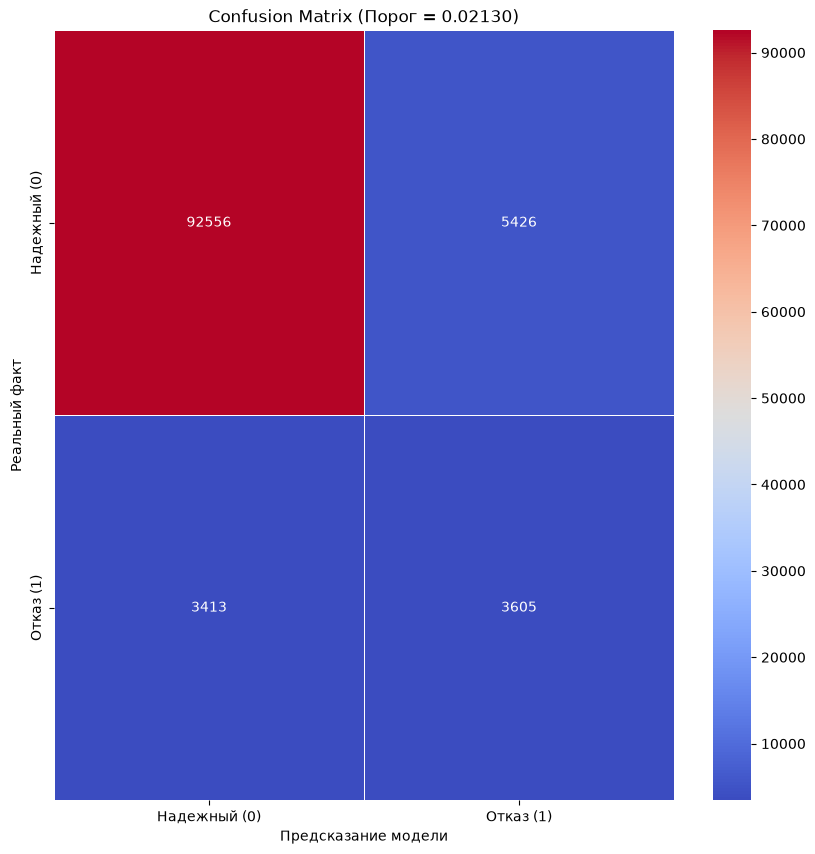

In [20]:
y_predicted = (probabilities >= best_threshold).astype(int)
confmat = confusion_matrix(y, y_predicted)
print(len(thresholds))
plt.figure(figsize=(10,10))
sns.heatmap(confmat, annot=True, fmt='d', cmap='coolwarm', linewidths=0.5,
    xticklabels=['Надежный (0)', 'Отказ (1)'],
    yticklabels=['Надежный (0)', 'Отказ (1)'],
)
plt.title(f'Confusion Matrix (Порог = {best_threshold:.5f})')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальный факт');


### 8. Интерпретация предсказаний через SHAP

SHAP - метод из теории игр. Он показывает не только насколько важен признак, но и как именно он влияет (например: «чем выше возраст, тем ниже риск просрочки»).

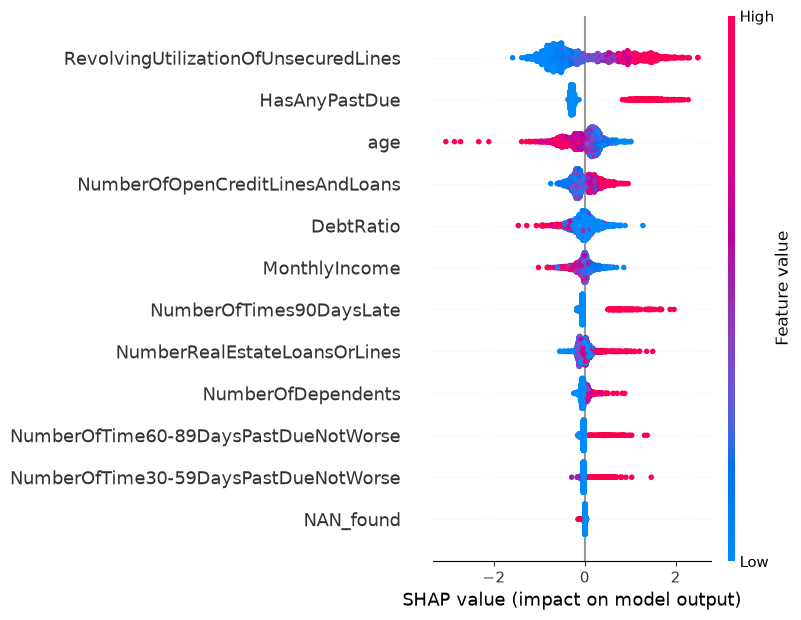

In [21]:
model = LGBMClassifier(
    random_state=1, n_estimators=300, max_depth=5
)
model.fit(x_train, y_train)
explainer = shap.TreeExplainer(model)
x_sample = x_train.sample(2000, random_state=1)
shap_values = explainer(x_sample)

plt.figure(figsize=(6,6))
shap.summary_plot(shap_values, x_sample)

RevolvingUtilizationOfUnsecuredLines: Признак обладает наивысшей важностью.  Низкий процент использования лимита (синий цвет) служит главным маркером надежности заемщика.

HasAnyPastDue / NumberOfTimes...: Все положительные значения (наличие факта задержки платежа) смещены строго в область положительных значений SHAP, оказывая мгновенный штрафной эффект на скоринговый балл.

age: Выявлена устойчивая обратная связь: высокий возраст клиента (красный спектр) сдвигает SHAP-значения влево, снижая итоговый риск дефолта. Молодой возраст заемщиков выступает фактором повышенного риска.

DebtRatio и MonthlyIncome: Признаки демонстрируют физически корректное поведение: высокий уровень ежемесячного дохода смещает оценку в сторону надежности.

NAN_found: Признак наличия пропусков показал околонулевые SHAP-значения для всей выборки. Сам факт отсутствия данных не несет никакой риска-ориентированной информации и может быть удален из финального набора данных без потери качества классификации.

### 9. Оптимизация гиперпараметров

In [22]:
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.ERROR)


def objective(trial):
    params = {
    'boosting_type': 'gbdt',
    'random_state': 1,
    'n_estimators': 1000,
    'verbosity': -1,
    'n_jobs': -1,

    'learning_rate': trial.suggest_float(
         'learning_rate', 0.01, 0.1
    ),
    'num_leaves': trial.suggest_int(
        'num_leaves', 15, 130
    ),
    'max_depth': trial.suggest_int(
        'max_depth', 3, 10
    ),
    'min_child_samples': trial.suggest_int(
          'min_child_samples', 20, 300
      ),
      'reg_alpha': trial.suggest_float(
          'reg_alpha', 1e-8, 10.0, log=True
      )


    }

    sk = StratifiedKFold(
        n_splits=5,
        random_state=1,
        shuffle=True
    )
    scores = []
    for train, val in sk.split(X, y):
        x_train = X.iloc[train]
        y_train = y.iloc[train]
        x_val = X.iloc[val]
        y_val = y.iloc[val]

        lgb = LGBMClassifier(**params)
        lgb.fit(
            x_train,
            y_train,
            eval_set=[(x_val, y_val)],
            callbacks=[early_stopping(stopping_rounds=30, verbose=False)]
        )

        y_ = lgb.predict_proba(x_val)[:, 1]
        roc_auc = roc_auc_score(y_val, y_)
        scores.append(roc_auc)
    return np.mean(scores)
study = optuna.create_study(direction='maximize')
print('Поиск лучших параметров с помощью Optuna (30 итераций)...')
study.optimize(objective, n_trials=30)
print(f'Оптимизированный ROC-AUC: {study.best_value:.5f}')
print('\nЛучшие найденные параметры:')
for key, value in study.best_params.items():
  print(f'"{key}": {value}')   


Поиск лучших параметров с помощью Optuna (30 итераций)...
Оптимизированный ROC-AUC: 0.86653

Лучшие найденные параметры:
"learning_rate": 0.038165047207166305
"num_leaves": 118
"max_depth": 3
"min_child_samples": 219
"reg_alpha": 9.456970982457966


### 10. Построение матрицы ошибок для модели с предустановленными гиперпараметрами

ROC-AUC в этом фолде 0.8487542877069894
ROC-AUC в этом фолде 0.8670567785496428
ROC-AUC в этом фолде 0.8564033178176371
ROC-AUC в этом фолде 0.8707773629887837
ROC-AUC в этом фолде 0.8609868597812567
Оптимальный порог: 0.2084
Максимальный F1-score: 0.4335


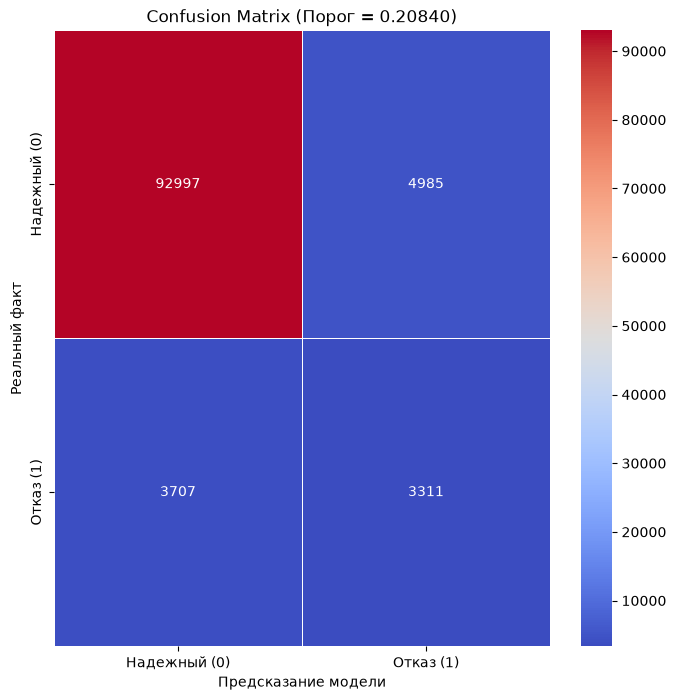

In [23]:
best = study.best_params
oof = np.zeros(y.shape[0])
scores = []
for train, test in StratifiedKFold(
    n_splits=5, shuffle=True, random_state=1
    ).split(X, y):
    x_train, x_test = X.iloc[train], X.iloc[test]
    y_train, y_test = y.iloc[train], y.iloc[test]
    model_ = LGBMClassifier(**best)
    model_.fit(
        x_train,
        y_train,
        eval_set=[(x_test, y_test)],
        callbacks=[early_stopping(stopping_rounds=30, verbose=False)],

    )
    y_pred = model_.predict_proba(x_test)[:, 1]
    oof[test] = y_pred 
    scores.append(roc_auc_score(y_test, y_pred))
    print(f'ROC-AUC в этом фолде {scores[-1]}')

threshold = 0.2107
indicies = (oof >= threshold).astype(int)

precisions, recalls, thresholds = precision_recall_curve(
    y, oof
)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f'Оптимальный порог: {best_threshold:.4f}')
print(f'Максимальный F1-score: {f1_scores[best_idx]:.4f}')

cmt = confusion_matrix(y, indicies)
plt.figure(figsize=(8,8))
sns.heatmap(cmt, annot=True, fmt='d', cmap='coolwarm', linewidths=0.5,
    xticklabels=['Надежный (0)', 'Отказ (1)'],
    yticklabels=['Надежный (0)', 'Отказ (1)'],
)
plt.title(f'Confusion Matrix (Порог = {best_threshold:.5f})')
plt.xlabel('Предсказание модели')
plt.ylabel('Реальный факт');



### 11. Финальная оценка качества. Графики ROC-AUC / Precision-Recall

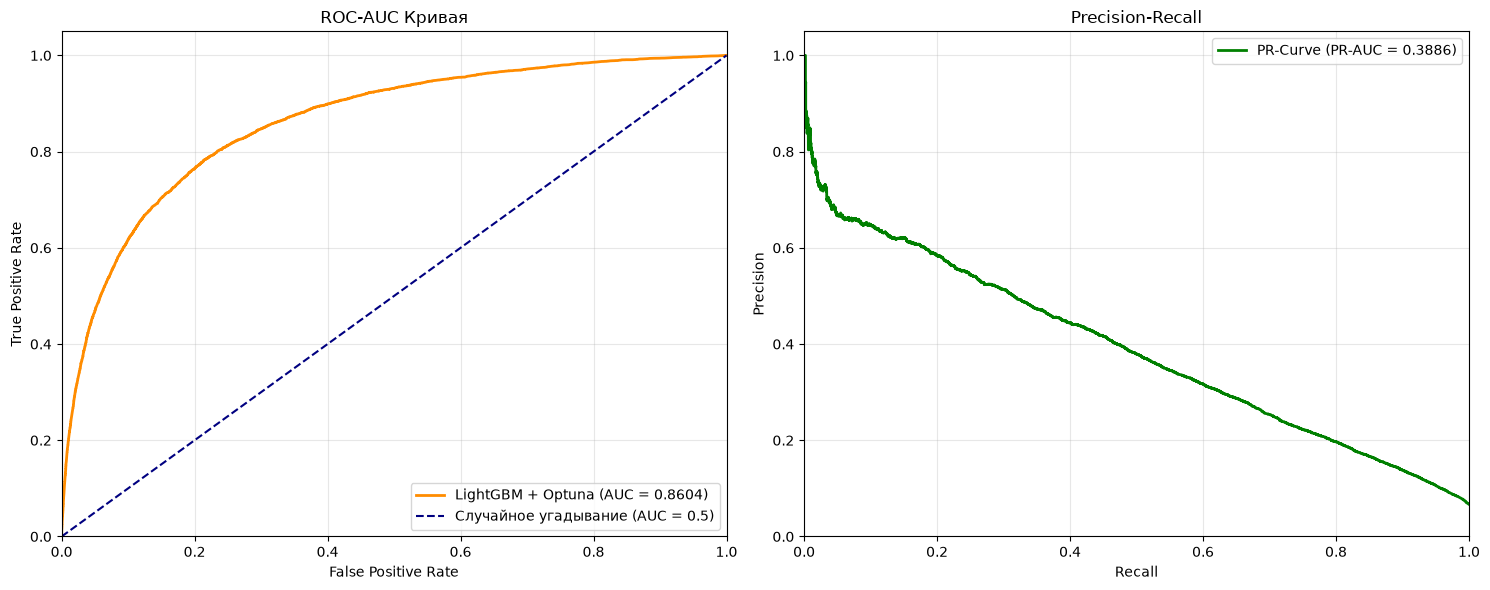

ROC-AUC Score      : 0.86045
Коэффициент Джини  : 0.72089 (72.1%)
PR-AUC Score       : 0.38857


In [24]:
roc_auc_val = roc_auc_score(y, oof)
gini_val = 2 * roc_auc_val - 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

fpr, tpr, _ = roc_curve(y, oof)
ax1.plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label=f'LightGBM + Optuna (AUC = {roc_auc_val:.4f})',
)
ax1.plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=1.5,
    linestyle='--',
    label='Случайное угадывание (AUC = 0.5)',
)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC-AUC Кривая')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

precision, recall, _ = precision_recall_curve(y, oof)
pr_auc = auc(recall, precision)
ax2.plot(
    recall,
    precision,
    color='green',
    lw=2,
    label=f'PR-Curve (PR-AUC = {pr_auc:.4f})',
)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'ROC-AUC Score      : {roc_auc_val:.5f}')
print(f'Коэффициент Джини  : {gini_val:.5f} ({gini_val * 100:.1f}%)')
print(f'PR-AUC Score       : {pr_auc:.5f}')